# batss CRN benchmarks

Each CRN below defines a `CRNSpec` (whose `benchmark_end_time` field sets the simulated end time for the runtime benchmark) plus a couple of per-CRN variables (`trajectory_n`, `trajectory_end_time`). To benchmark and plot a CRN:

1. Run its definition cell.
2. Run the **Run** cell at the bottom.

Runtime measurements are cached to JSON under `DATA_DIR`, so rerunning the **Run** cell skips already-computed `(backend, n)` pairs. Plots are also written there, to filenames derived from the `CRNSpec`.

In [1]:
import batss as bt
from batss.benchmarking import CRNSpec, benchmark_runtimes, plot_runtimes, plot_trajectory

DATA_DIR = "data"

## Dimerization

$M + M \rightleftharpoons D$, reversible with both rates 1.

In [7]:
m, d = bt.species("M D")
spec = CRNSpec(
    name="Dimerization",
    rxns=[
        (m + m >> d).k(1),
        (d >> m + m).k(1),
    ],
    inits_from_n=lambda n: {m: n},
    benchmark_end_time=0.5,
)
trajectory_n = 10**6
trajectory_end_time = 2.0

## Lotka–Volterra

$R + F \to 2F$, $R \to 2R$, $F \to \varnothing$, all at rate 1. Half-and-half initial split.

In [3]:
r, f = bt.species("R F")
spec = CRNSpec(
    name="Lotka Volterra",
    rxns=[
        (r + f >> 2 * f).k(1),
        (r >> 2 * r).k(1),
        (f >> None).k(1),
    ],
    inits_from_n=lambda n: {r: n // 2, f: n - n // 2},
    benchmark_end_time=1.0,
)
trajectory_n = 10**5
trajectory_end_time = 20.0

## Rössler

Three-species chaotic oscillator; rates as in `rossler_plotting.py`. Thirds initial split.

In [4]:
x1, x2, x3 = bt.species("X1 X2 X3")
spec = CRNSpec(
    name="Rössler-Willamowski",
    rxns=[
        (x1 >> 2 * x1).k(30),
        (2 * x1 >> x1).k(0.5),
        (x2 + x1 >> 2 * x2).k(1),
        (x2 >> None).k(10),
        (x1 + x3 >> None).k(1),
        (x3 >> 2 * x3).k(16.5),
        (2 * x3 >> x3).k(0.5),
    ],
    inits_from_n=lambda n: {x1: n // 3, x2: n // 3, x3: n // 3},
    benchmark_end_time=1.0,
)
trajectory_n = 10**4
trajectory_end_time = 8.0

# Oregonator

Oregonator model of the Belousov–Zhabotinsky oscillatory reactions.

In [5]:
x1, x2, x3 = bt.species("X1 X2 X3")
# The two bimolecular rates are reduced from the textbook Oregonator values
# (1.6e9 and 4e7), which are calibrated for concentrations ~1e-7. Here the
# simulators use volume=n and the counts are ~n, i.e. concentration ~1, so the
# textbook rates make the X1+X2 and 2X1 annihilations ~1e6x too fast: X1 and X2
# are wiped out instantly and everything collapses to 0. 1000 and 40 bring the
# limit cycle into the count~n regime so it actually oscillates.
spec = CRNSpec(
    name="Oregonator",
    rxns = [
        (x2 >> x1).k(0.0871),
        (x2 + x1 >> None).k(1000),       # textbook: 1.6e9
        (x1 >> 2 * x1 + x3).k(520),
        (2 * x1 >> None).k(40),          # textbook: 4e7
        (x3 >> x2).k(443.324),
        (x3 >> None).k(2.676),
    ],
    # Initial condition placed on the limit cycle (quiescent phase, X1 at its
    # minimum) so the trajectory oscillates immediately with no startup transient.
    # These concentrations sum to ~0.54, not 1, which is why _batss_sim passes
    # volume=n explicitly -- otherwise batss normalizes the counts to sum to 1,
    # landing off the cycle. Equal thirds or 1:4:1 instead spiral in ~2 periods.
    inits_from_n = lambda n: {x1: int(0.0029 * n), x2: int(0.5358 * n), x3: int(0.0034 * n)},
    benchmark_end_time=1.0,
)
# With working rates the CRN actually oscillates (counts stay ~n), so batss does
# real work: n=1e6 takes ~100s. The period is ~0.7, so t=5 shows ~7 oscillations.
trajectory_n = 10**8
trajectory_end_time = 5.0

## Run

Runs benchmarks and produces both plots for whichever CRN cell above was run most recently.

running batss for Oregonator at n=$10^{8}$


  0%|          | 0/5.0 [00:00<?, ? time simulated/s]

<Axes: title={'center': 'Oregonator: batss, n=$10^{8}$'}, xlabel='time', ylabel='count'>

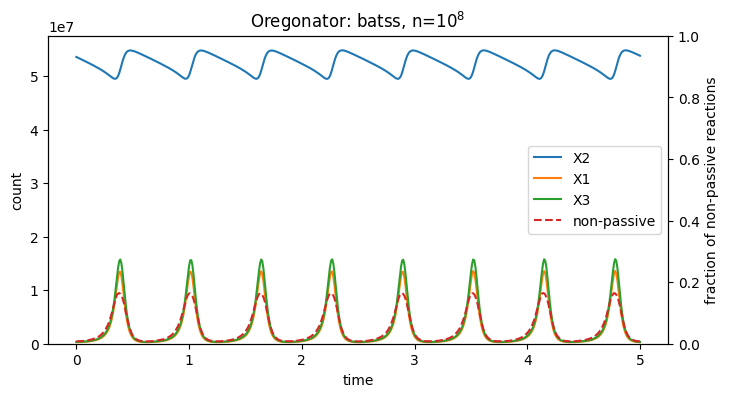

In [ ]:
pop_sizes = [10**e for e in range(3, 11)]
benchmark_runtimes(
    spec,
    pop_sizes=pop_sizes,
    data_dir=DATA_DIR,
    overwrite=True,
)
plot_runtimes(
    spec,
    data_dir=DATA_DIR,
)
plot_trajectory(
    spec,
    n=trajectory_n,
    end_time=trajectory_end_time,
    data_dir=DATA_DIR,
    seed=1,
    num_samples=500,
    # heuristic=True,
    # backend='rebop',
    # loc="lower right",
)